In [2]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
#sys.path.append("/user/christoph.wald/u15287/ultralytics")

from ultralytics import YOLO
import time
import os
import json
import cv2
import shutil
from modules_prediction import *
from modules import load_yolo_labels
from modules_evaluation import *
import random

import os
import yaml

In [3]:
model_number = 3
model = YOLO(f"/user/christoph.wald/u15287/insect_pest_detection/2_3_supervised_training/runs/detect/train{model_number}/weights/best.pt")

In [17]:
image_dir = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/train"
label_dir = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles_mininside08/labels"
output_dir = f"/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/predictions"
os.makedirs(output_dir, exist_ok=True)

In [8]:
filenames = os.listdir(image_dir)
filename = filenames[3]
filename

'BRAIIM_0003.jpg'

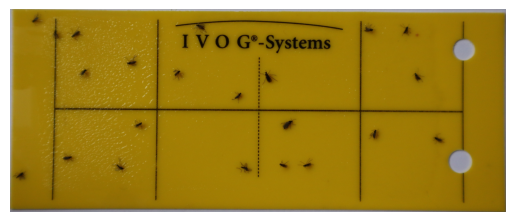

In [12]:
image_path = os.path.join(image_dir, filename)
image = cv2.imread(image_path)
from modules_segmentation import show
show(image)

In [14]:
# predicts on the full images (with stride 420)
boxes, confs, class_ids = sliding_window_prediction(image, model)
if boxes.numel() > 0:
                boxes, confs, class_ids = nms(boxes, confs, class_ids, iou_threshold=0.4, device=model.device)
                boxes, confs, class_ids = filter_mostly_contained_boxes(boxes, confs, class_ids, threshold=0.5)
                #print(f"Predicted: {boxes.size(0)}")
boxes

tensor([[3136.9180, 1267.3362, 3339.4939, 1439.3860],
        [  39.4984, 1880.8285,  202.8351, 2003.2827],
        [4680.3438,  724.0469, 4808.8647,  861.1825],
        [3116.7302, 1753.7161, 3257.6353, 1870.5247],
        [ 784.7881,  676.2678,  935.8427,  795.8138],
        [1211.8800, 1784.8639, 1359.6522, 1905.8633],
        [4904.8433, 1466.7723, 5070.5864, 1574.7206],
        [2940.0000,  699.5197, 3135.1243,  889.7175],
        [ 683.8127,  232.6316,  864.7482,  358.1405],
        [1438.8086, 1295.9270, 1572.0170, 1410.3960],
        [4559.0430,  182.3222, 4672.5142,  318.1269],
        [3385.6704, 1750.7808, 3554.2439, 1870.0267],
        [ 233.0021,   47.5771,  362.8243,  186.9450],
        [1330.2346,  514.6180, 1502.8475,  690.2555],
        [ 584.9562, 1688.9142,  754.9258, 1788.1184],
        [1882.2626,  687.0695, 2033.9901,  844.6576],
        [2657.7678, 1768.0491, 2816.8440, 1899.1327],
        [4200.0000, 1382.0011, 4313.0239, 1539.9629],
        [2566.6404,  951.779

In [15]:
pred_tiles_data = get_labels_per_tile_tensor(image, boxes, class_ids, confs)
pred_tiles_data

[tensor([[1.0000, 0.4655, 0.1832, 0.2028, 0.2178, 0.6621]]),
 tensor([[0.0000, 0.5223, 0.4615, 0.2827, 0.1961, 0.7092]]),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([[1.0000, 0.4408, 0.6995, 0.1565, 0.0864, 0.2688]]),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([[0.0000, 0.3689, 0.3778, 0.1828, 0.1698, 0.4633]]),
 tensor([[0.0000, 0.3372, 0.3910, 0.1773, 0.2122, 0.6888]]),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([], size=(0, 6)),
 tensor([[0.0000, 0.6567, 0.4626, 0.2360, 0.1868, 0.7619]]),
 tensor([[0.0000, 0.8383, 0.2538, 0.2697, 0.2744, 0.6561]]),
 tensor([[0.0000, 0.1508, 0.2538, 0.2697, 0.2744, 0.6561],
         [3.0000, 0.4136, 0.7359, 0.0588, 0.0665, 0.2588]]),
 tensor([[0.0000, 0.3096, 0.5092, 0.2371, 0.2462, 0.6074]]),
 tensor([[0.0000, 0.6993, 0.8998, 0.2529, 0.2003, 0.5152]]),
 tensor([[0.0000, 0.6212, 0.5541, 0.3049, 0.2972, 0.7277],
         [1.

In [18]:
label_tiles_data = load_label_tiles(label_dir, filename)
label_tiles_data

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:

    # output dict structured by FN/FP/TP -> species -> image
    json_results = {"FN": {}, "FP": {}, "TP": {}}

            

            
                   
            
        


            
            print(pred_tiles_data)
            print("Loaded labels.")
            print(label_tiles_data)
            results = []

            # Assuming you’re looping through images somewhere above this point
            species = filename.split("_")[0]  # extract species name from filename

            # Create output directory for this species' visualizations
            tile_save_dir = os.path.join(output_dir, "visualizations", species)
            os.makedirs(tile_save_dir, exist_ok=True)

            # Loop through all tiles
            for tile_id, (pred_tile, gt_tile) in enumerate(zip(pred_tiles_data, label_tiles_data)):
                # pred_tile and gt_tile should each contain boxes, classes, and possibly scores

                # --- Get tile coordinates and crop ---
                tile_image = get_tile_image(image, tile_id, tile_size=640, stride=440)

                # --- Extract data from per-tile tensors ---
                if pred_tile is not None and len(pred_tile) > 0:
                # Assuming columns: x1, y1, x2, y2, class_id, confidence
                    pred_boxes = pred_tile[:, :4]
                    pred_classes = pred_tile[:, 4]
                else:
                    pred_boxes = torch.empty((0, 4))
                    pred_classes = torch.empty((0,))
                if gt_tile is not None and len(gt_tile) > 0:
                    gt_boxes = gt_tile[:, :4]
                    gt_classes = gt_tile[:, 4]
                else:
                    gt_boxes = torch.empty((0, 4))
                    gt_classes = torch.empty((0,))

                # --- Make sure data is on CPU and NumPy-friendly ---
                pred_boxes = pred_boxes.detach().cpu().numpy() if torch.is_tensor(pred_boxes) else np.array(pred_boxes)
                pred_classes = pred_classes.detach().cpu().numpy() if torch.is_tensor(pred_classes) else np.array(pred_classes)
                gt_boxes = gt_boxes.detach().cpu().numpy() if torch.is_tensor(gt_boxes) else np.array(gt_boxes)
                gt_classes = gt_classes.detach().cpu().numpy() if torch.is_tensor(gt_classes) else np.array(gt_classes)

                # --- Compose output filename ---
                tile_filename = f"{os.path.splitext(filename)[0]}_tile{tile_id}.jpg"
                tile_save_path = os.path.join(tile_save_dir, tile_filename)

                # --- Draw and save visualization ---
                draw_boxes_on_tile(
                    tile_image,
                    pred_boxes,
                    pred_classes,
                    gt_boxes,
                    gt_classes,
                    tile_save_path
                )

        print(f"Saved visualizations for {filename} in {tile_save_dir}")

        '''
            # This is the per-tile loop:
            for tile_id, (pred, label) in enumerate(zip(pred_tiles_data, label_tiles_data)):
                # pred = predictions for tile i
                # label = labels for tile i

                
                if pred.numel() == 0:
                    pred_boxes = torch.empty((0, 4), device='cuda')
                    pred_classes = torch.empty((0,), dtype=torch.long, device='cuda')
                    pred_scores = torch.empty((0,), device='cuda')
                else:
                    pred_boxes = pred[:, 1:5]
                    pred_classes = pred[:, 0].long()
                    pred_scores = pred[:, 5]

                if label.numel() == 0:
                    gt_boxes = torch.empty((0, 4), device='cuda')
                    gt_classes = torch.empty((0,), dtype=torch.long, device='cuda')
                else:
                    gt_boxes = label[:, 1:5]
                    gt_classes = label[:, 0].long()

                tp, fp, fn = compare_labels_vectorized(
                    pred_boxes, pred_classes, pred_scores, gt_boxes, gt_classes
                )
                species = filename.split("_")[0]  # extract species from filename

                # Save visualization of each tile
                tile_save_dir = os.path.join(output_dir, "visualizations", species)
                os.makedirs(tile_save_dir, exist_ok=True)
                tile_filename = f"{os.path.splitext(filename)[0]}_tile{tile_id}.jpg"
                tile_save_path = os.path.join(tile_save_dir, tile_filename)

                # Get the actual tile image (you can get it from your get_labels_per_tile_tensor logic)
                # Assuming your tiles correspond to known image crops, use this helper:
                tile_image = get_tile_image(image, tile_id)  # <- implement if not existing
                # OR, if you already have per-tile crops in memory, pass them here

                draw_boxes_on_tile(
                    tile_image, 
                    pred_boxes.detach().cpu().numpy(), 
                    pred_classes.detach().cpu().numpy(),
                    gt_boxes.detach().cpu().numpy(),
                    gt_classes.detach().cpu().numpy(),
                    tile_save_path
                )

                

                # --- Add entries to JSON with tile_id ---
                for category, items in zip(["TP", "FP", "FN"], [tp, fp, fn]):
                    boxes, classes, scores = items if category != "FN" else (*items, [None]*len(items[0]))
                    if len(classes) > 0:
                        json_results.setdefault(category, {}).setdefault(species, {}).setdefault(filename, [])
                        for cls, box, score in zip(classes, boxes, scores):
                            entry = {"tile_id": tile_id}
                            if category != "FN":
                                entry["prediction"] = [cls, *box, score]
                            else:
                                entry["prediction"] = [cls, *box]
                            #print(category,entry)
                            json_results[category][species][filename].append(entry)
        '''
    with open(os.path.join(output_dir, f'predictions_{output_number}.json'), 'w') as f:
        json.dump(json_results, f, indent=4)

    end = time.time()
    print(f"Predicting took {end-start:.2f} seconds.")
    start = end